In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

** <font size='6' color='red'>ch02. 한글 형태소 분석</font> **
# 1. 자연어 처리
- 자연어 : 일상적인 언어
- 자연어 처리 분야:
    * 자연어 이해 : 형태소분석 -> postagging -> 의미분석, 시각화
    * 자연어 생성 : RNN, LSTM, GRU, ..., encoder-decoder알고리즘 -> 트랜스포머알고리즘
- 활용분야 : 트렌드분석, 탐색적분석, 맞춤법검사, 번역기, 챗봇
# 2. 자연어 이해 처리 절차
- 전처리 : 단어, 어절 추출
- 분석 후보 생성 : 형태소 분리, 품사태깅(pos tagging)
- 제약 조건 (불용어 처리) : 규칙 확인
- 분석 : 시각화(워드클라우드), 연관분석, RNN, LSTM, GRU, ...
# 3. 한글형태소 분석 엔진(Konlpy, ...)
- 공통기능 : morphs(형태소 나누기), nouns(명사추출), pos(형태소로 나누어 품사 태그)

- Konlpy (pip install konlpy : jpype1라이브러리를 의존)
    * HanNanum : 자바로 만든 형태소 분석기(JAVA_HOME 시스템환경변수, Path 설정)
    * Kkma     : 자바로 만든 형태소 분석기(JAVA_HOME 시스템환경변수, Path 설정)
    * Komora   : 자바로 만든 형태소 분석기(JAVA_HOME 시스템환경변수, Path 설정)
    * Okt
- Mecab (pip install python-mecab-ko)
    * MeCab : C++로 만든 형태소 분석기. 저사양 환경에서 사용 가능. 다국어 바인딩 지원

In [1]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [2]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로 많이 사용되는 언어입니다 '''

# 3.1 HanNanum

In [4]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath=None,
                   max_heap_size=1024) # 기본값: 1024, '10m', '1g' : 텍스트 사이즈가 클 때 선택적 사용, 최대 4g
hannanum.analyze(text) # ntag=69로 형태소분석 후보

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('기', 'etn'), ('도', 'jxc')]],
 [[('하', 'pvg'), ('ㄴ', 'etm')],
  [('한', 'nnc')],
  [('한', 'ncn')],
  [('한', 'nbn')],
  [('하', 'px'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [[('전세계', 'ncn'), ('에서', 'jca')],
  [('전세', 'ncn'), ('계', 'ncn'), ('에서', 'jca')],
  [('전', 'xp'), ('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [[('많', 'paa'), ('이', 'xsa')], [('많이', 'mag')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]]]

- pos tagging chart 다운로드
    * 구글에서 konlpy docs 검색후 https://konlpy.org/
    * api 메뉴 -> "Comparison between POS tagging classes"클릭 -> Korean POS tags comparison chart클릭

In [6]:
# 형태소 분석: morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13번', '째', '로', '많', '이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [7]:
# 명사만 추출
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [8]:
# 품사 태그
print(hannanum.pos(text, ntags=9)) # 품사갯수 기본값: 9

[('아름답', 'P'), ('지만', 'E'), ('다소', 'M'), ('복잡', 'N'), ('하', 'X'), ('기', 'E'), ('도', 'J'), ('하', 'P'), ('ㄴ', 'E'), ('한국어', 'N'), ('는', 'J'), ('전세계', 'N'), ('에서', 'J'), ('13번', 'N'), ('째', 'X'), ('로', 'J'), ('많', 'P'), ('이', 'X'), ('사용', 'N'), ('되', 'X'), ('는', 'E'), ('언어', 'N'), ('이', 'J'), ('ㅂ니다', 'E')]


In [9]:
print(hannanum.pos(text, ntags=22))

[('아름답', 'PA'), ('지만', 'EC'), ('다소', 'MA'), ('복잡', 'NC'), ('하', 'XS'), ('기', 'ET'), ('도', 'JX'), ('하', 'PV'), ('ㄴ', 'ET'), ('한국어', 'NC'), ('는', 'JX'), ('전세계', 'NC'), ('에서', 'JC'), ('13', 'NN'), ('번', 'NB'), ('째', 'XS'), ('로', 'JC'), ('많', 'PA'), ('이', 'XS'), ('사용', 'NC'), ('되', 'XS'), ('는', 'ET'), ('언어', 'NC'), ('이', 'JP'), ('ㅂ니다', 'EF')]


In [11]:
# 퀴즈1. text에서 형용사(PA)만 추출
postagged_text = hannanum.pos(text, ntags=22)
PA_tagged_word = [token for token, tag in postagged_text if tag == 'PA']
PA_tagged_word

['아름답', '많']

In [22]:
# 퀴즈2. text에서 명사만 추출
# Ns_tagged_word = [token for token, tag in postagged_text if (tag=='NC')|(tag=='NQ')|(tag=='NB')|(tag=='NN')|(tag=='NP')]
# Ns_tagged_word = [token for token, tag in postagged_text if taf.find('N')!=-1]
Ns_tagged_text = [token for token, tag in postagged_text if tag in ('NC', 'NQ', 'NB', 'NN', 'NP')]
print(Ns_tagged_word,'\n',hannanum.nouns(text))

['복잡', '한국어', '전세계', '13', '번', '사용', '언어'] 
 ['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [18]:
# 퀴즈3. text에서 보통명사만 추출
NC_tagged_text = [token for token, tag in postagged_text if tag in ('NC')]
NC_tagged_text

['복잡', '한국어', '전세계', '사용', '언어']

## 3.2 Kkma

In [3]:
from konlpy.tag import Kkma
kkma = Kkma(jvmpath=None,
           max_heap_size=1024) # 필요시 scale 지정 ex) '4m', '4g'
print(kkma.morphs(text)) # 형태소 추출

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전세계', '에서', '13', '번째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [24]:
print(kkma.nouns(text)) # 명사 추출

['복잡', '한국어', '전세계', '13', '13번째', '번째', '사용', '언어']


In [25]:
# 품사 태깅
print(kkma.pos(text)) # ntags 지정 불가 (무조건 56으로)

[('아름답', 'VA'), ('지만', 'ECE'), ('다소', 'MAG'), ('복잡', 'NNG'), ('하', 'XSV'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MDN'), ('한국어', 'NNG'), ('는', 'JX'), ('전세계', 'NNG'), ('에서', 'JKM'), ('13', 'NR'), ('번째', 'NNB'), ('로', 'JKM'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETD'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EFN')]


In [27]:
# 명사 추출
tagged_text = kkma.pos(text)
print([token for token, tag in tagged_text if tag in ('NNG','NNP','NNB','NNM')])
print(kkma.nouns(text))

['복잡', '한국어', '전세계', '번째', '사용', '언어']
['복잡', '한국어', '전세계', '13', '13번째', '번째', '사용', '언어']


In [28]:
# 보통명사(NNG) + 고유명사(NNP)
print([token for token, tag in tagged_text if tag in ('NNG','NNP')])

['복잡', '한국어', '전세계', '사용', '언어']


## 3.3 Komoran

In [3]:
from konlpy.tag import Komoran
komoran = Komoran() # max_heap_size=1024
# 형태소 분석
print(komoran.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다']


In [5]:
# 명사 추출
tagged_text = komoran.pos(text)
print(komoran.nouns(text))

['한국어', '전', '세계', '번', '사용', '언어']


In [35]:
# 품사 태깅
print(komoran.pos(text)) # ntags 지정 불가 

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNP'), ('는', 'JX'), ('전', 'NNG'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNB'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EC')]


In [6]:
# 보통명사(NNG) + 고유명사(NNP)
print([token for token, tag in tagged_text if tag in ('NNG','NNP')])

['한국어', '전', '세계', '사용', '언어']


##  3.4 Twitter (Okt : Open Korean Text)
- konlpy v0.4.5부터 Twitter -> Okt로 바뀜

In [7]:
import konlpy
konlpy.__version__

'0.6.0'

In [14]:
%%time
from konlpy.tag import Twitter, Okt
# okt = Twitter()
okt = Okt() # max_heap_size
# print('구 추출 :', okt.phrases(text))
print('형태소 추출 :', okt.morphs(text))
print('명사 추출 :', okt.nouns(text))
tagged_text = okt.pos(text)
print('품사태깅을 이용한 명사 추출 :', [token for token, tag in tagged_text if tag=='Noun'])
print('품사 태깅 :', tagged_text)

형태소 추출 : ['아름답지만', '다소', '복잡하기도', '한', '한국어', '는', '전세계', '에서', '13', '번', '째', '로', '많이', '사용', '되는', '언어', '입니다']
명사 추출 : ['다소', '한국어', '전세계', '번', '사용', '언어']
품사태깅을 이용한 명사 추출 : ['다소', '한국어', '전세계', '번', '사용', '언어']
품사 태깅 : [('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡하기도', 'Adjective'), ('한', 'Verb'), ('한국어', 'Noun'), ('는', 'Josa'), ('전세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('많이', 'Adverb'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective')]
CPU times: total: 93.8 ms
Wall time: 31.9 ms


## 3.5 MeCap
- pip install python-mecab-ko

In [15]:
%%time
from mecab import MeCab
mecab = MeCab() # 힙메모리 사이즈 지정이 안 됨

print('형태소 추출 :', mecab.morphs(text))
print('명사 추출 :', mecab.nouns(text))
tagged_text = mecab.pos(text) # ntags 조정 불가 (43개만 있음)
print('품사태깅을 이용한 명사 추출 :', [token for token, tag in tagged_text if tag in ('NNG','NNP','NNB','NNBC','NR','NP')])
print('품사 태깅 :', tagged_text)

형태소 추출 : ['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '입니다']
명사 추출 : ['한국어', '세계', '번', '사용', '언어']
품사태깅을 이용한 명사 추출 : ['한국어', '세계', '번', '사용', '언어']
품사 태깅 : [('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'MM'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNBC'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('입니다', 'VCP+EC')]
CPU times: total: 0 ns
Wall time: 9.46 ms


# 4. 말뭉치

In [16]:
# 영어 말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')

In [40]:
# 한국어 말뭉치
# %pip show konlpy
from konlpy.corpus import kolaw
consti = kolaw.open('constitution.txt').read() # readlines :한줄씩 list로 반환
print('글자수 :', len(data))
print('%r' % (data))

글자수 : 18884
'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임시정부의 법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의 사명에 입각하여 정의·인도와 동포애로써 민족의 단결을 공고히 하고, 모든 사회적 폐습과 불의를 타파하며, 자율과 조화를 바탕으로 자유민주적 기본질서를 더욱 확고히 하여 정치·경제·사회·문화의 모든 영역에 있어서 각인의 기회를 균등히 하고, 능력을 최고도로 발휘하게 하며, 자유와 권리에 따르는 책임과 의무를 완수하게 하여, 안으로는 국민생활의 균등한 향상을 기하고 밖으로는 항구적인 세계평화와 인류공영에 이바지함으로써 우리들과 우리들의 자손의 안전과 자유와 행복을 영원히 확보할 것을 다짐하면서 1948년 7월 12일에 제정되고 8차에 걸쳐 개정된 헌법을 이제 국회의 의결을 거쳐 국민투표에 의하여 개정한다.\n\n       제1장 총강\n  제1조 ① 대한민국은 민주공화국이다.\n②대한민국의 주권은 국민에게 있고, 모든 권력은 국민으로부터 나온다.\n  제2조 ① 대한민국의 국민이 되는 요건은 법률로 정한다.\n②국가는 법률이 정하는 바에 의하여 재외국민을 보호할 의무를 진다.\n  제3조 대한민국의 영토는 한반도와 그 부속도서로 한다.\n  제4조 대한민국은 통일을 지향하며, 자유민주적 기본질서에 입각한 평화적 통일 정책을 수립하고 이를 추진한다.\n  제5조 ① 대한민국은 국제평화의 유지에 노력하고 침략적 전쟁을 부인한다.\n②국군은 국가의 안전보장과 국토방위의 신성한 의무를 수행함을 사명으로 하며, 그 정치적 중립성은 준수된다.\n  제6조 ① 헌법에 의하여 체결·공포된 조약과 일반적으로 승인된 국제법규는 국내법과 같은 효력을 가진다.\n②외국인은 국제법과 조약이 정하는 바에 의하여 그 지위가 보장된다.\n  제7조 ① 공무원은 국민전체에 대한 봉사자이며, 국민에 대하여 책임을 진다.\n②공무원의 신분과 정치적 중립성은 법률이 정하는 바에 의하여 보장된다

# 5. 워드 클라우드
- pip install wordcloud

In [30]:
# 말뭉치에서 단어 추출 (특수문자 제외)
from nltk.tokenize import RegexpTokenizer
from nltk.tag      import pos_tag
ret = RegexpTokenizer('[a-zA-Z0-9]{2,}') # '[\w]'
words = ret.tokenize(emma)
# 명사(고유명사 제외)만 추출
emma_tags = pos_tag(words)
nouns_list = [token for token, tag in emma_tags if tag in ('NN', 'NNS')]
print('추출된 명사 갯수 :', len(nouns_list), '\t단어 종류수 :', len(set(nouns_list)))
print('noun_list : ', nouns_list[:10])
emma_nouns = ' '.join(nouns_list)
print('워드클라우드에 필요한 내용 :', emma_nouns[:100])

추출된 명사 갯수 : 22329 	단어 종류수 : 3450
noun_list :  ['Emma', 'clever', 'home', 'disposition', 'blessings', 'existence', 'years', 'world', 'daughters', 'indulgent']
워드클라우드에 필요한 내용 : Emma clever home disposition blessings existence years world daughters indulgent father consequence 


In [29]:
l = ['abc', 'bcd', 'cde', 'abc']
' '.join(l)

'abc bcd cde abc'

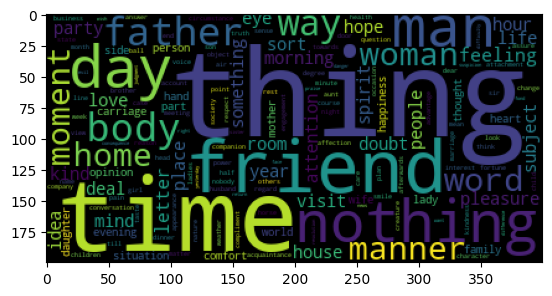

In [32]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt
wordC = WordCloud()
wordC.generate(emma_nouns)

plt.imshow(wordC)
plt.show()

- 컬러맵
    https://matplotlib.org/stable/users/explain/colors/colormaps.html

<function matplotlib.pyplot.show(close=None, block=None)>

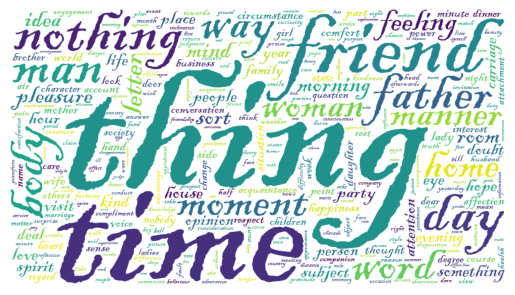

In [51]:
wordCl = WordCloud(
                font_path='C:/Windows/Fonts/ITCBLKAD.TTF',
                width=900, # 생성될 이미지 가로길이
                height=500,
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최개갯수
                relative_scaling=0.3,  # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis',
#                 max_font_size=80, # 최대 폰트 사이즈
                min_font_size=10, # 최소 폰트 사이즈
)
wordCl.generate(emma_nouns)
plt.imshow(wordCl)
plt.axis('off')
plt.show

In [49]:
# 한글 말뭉치 data로 워드클라우드 시각화
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab      import MeCab
analyzer = MeCab()
# noun_consti1 = analyzer.nouns(consti)
noun_consti2 = [word for word, tag in analyzer.pos(consti) if tag in ('NNG', 'NNP')]
# print(len(noun_consti1))
# print(len(noun_consti2))
consti_noun = ' '.join(noun_consti2)
consti_noun[:100]

'대한민국 헌법 역사 전통 국민 운동 건립 대한민국 임시 정부 법통 불의 항거 민주 이념 계승 조국 민주 개혁 평화 통일 사명 입각 정의 인도 동포 애 민족 단결 사회 폐습 불의 타'

<function matplotlib.pyplot.show(close=None, block=None)>

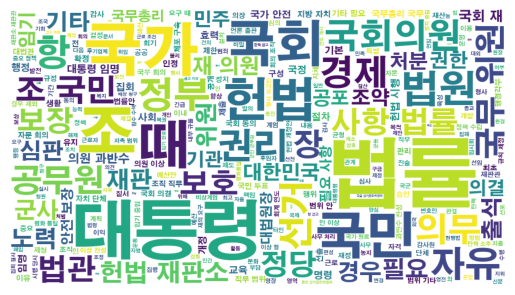

In [56]:
wordCl = WordCloud(
                font_path='C:/Windows/Fonts/H2GTRE.TTF',
                width=900, # 생성될 이미지 가로길이
                height=500,
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최개갯수
                relative_scaling=0.5,  # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis',
#                 max_font_size=80, # 최대 폰트 사이즈
#                 min_font_size=10, # 최소 폰트 사이즈
)
wordCl.generate(consti_noun)
plt.imshow(wordCl)
plt.axis('off')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

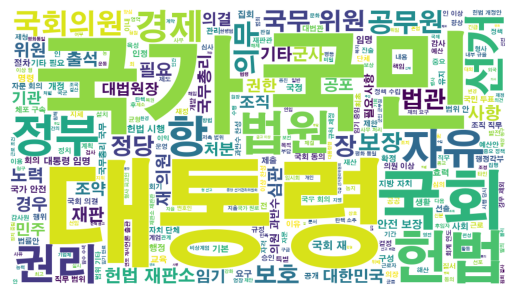

In [60]:
# 불용어 처리(불용어 지정 + 불용어 사전)
from wordcloud import STOPWORDS
불용어 = STOPWORDS | {'대통령', '법률'} # | : 집합 합연산자
불용어 = {'대통령', '법률'}
불용어 = set(['법률', '조', '때'])

wordCl = WordCloud(
                font_path='/data/NanumPenScript-Regular.ttf',
                width=900, # 생성될 이미지 가로길이
                height=500,
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최개갯수
                relative_scaling=0.5,  # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis',
#                 max_font_size=80, # 최대 폰트 사이즈
#                 min_font_size=10, # 최소 폰트 사이즈
                stopwords=불용어,
)
wordCl.generate(consti_noun)
plt.imshow(wordCl)
plt.axis('off')
plt.show

(468, 720, 3)

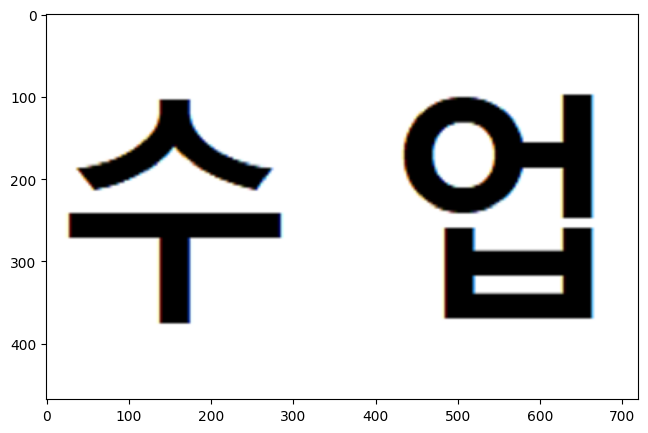

In [81]:
# 마스킹 : 워드클라우드를 지정된 마스크 이미지에 맞도록 설정
# 이미지를 넘파이 배열로 만드는 방법 1
from PIL import Image
import numpy as np
img = Image.open('data/test.png')
mask = np.array(img)
plt.figure(figsize=(9,5))
plt.imshow(mask)
mask.shape

In [ ]:
# 이미지를 넘파이 배열로 만드는 방법 2
import cv2
# %pip install opencv-contrib-python
mask = cv2.imread('data/test.png'
#                   , cv2.IMREAD_GRAYSCALE
                 )
plt.imshow(mask)
mask.shape

<function matplotlib.pyplot.show(close=None, block=None)>

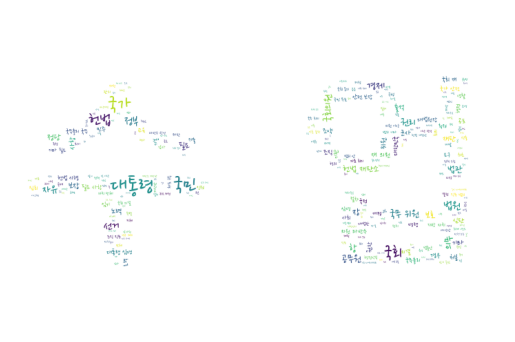

In [83]:
from wordcloud import STOPWORDS
불용어 = STOPWORDS | {'대통령', '법률'} # | : 집합 합연산자
불용어 = {'대통령', '법률'}
불용어 = set(['법률', '조', '때'])

wordCl = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                width=900, # 생성될 이미지 가로길이
                height=500,
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최개갯수
                relative_scaling=0.5,  # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis',
#                 max_font_size=80, # 최대 폰트 사이즈
#                 min_font_size=10, # 최소 폰트 사이즈
                stopwords=불용어,
                mask=mask,
)
wordCl.generate(consti_noun)
plt.imshow(wordCl)
plt.axis('off')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

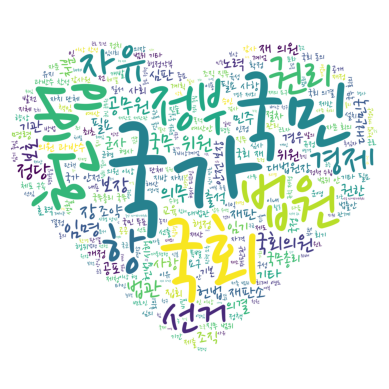

In [91]:
mask2 = cv2.imread('data/heart.jpg')
# plt.imshow(mask2)
# mask2.shape

from wordcloud import STOPWORDS
불용어 = STOPWORDS | {'대통령', '법률'} # | : 집합 합연산자
불용어 = {'대통령', '법률'}
불용어 = set(['대통령', '법률', '조', '때'])

wordCl = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                width=1200, # 생성될 이미지 가로길이
                height=1200,
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최개갯수
                relative_scaling=0.2,  # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis',
#                 max_font_size=80, # 최대 폰트 사이즈
#                 min_font_size=10, # 최소 폰트 사이즈
                stopwords=불용어,
                mask=mask2,
)
wordCl.generate(consti_noun)
plt.imshow(wordCl)
plt.axis('off')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

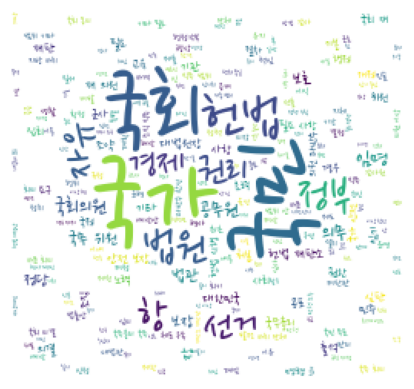

In [93]:
mask3 = cv2.imread('data/test2.jpg')
mask3.shape

from wordcloud import STOPWORDS
불용어 = STOPWORDS | {'대통령', '법률'} # | : 집합 합연산자
불용어 = {'대통령', '법률'}
불용어 = set(['대통령', '법률', '조', '때'])

wordCl = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                width=1200, # 생성될 이미지 가로길이
                height=1200,
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최개갯수
                relative_scaling=0.2,  # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis',
#                 max_font_size=80, # 최대 폰트 사이즈
#                 min_font_size=10, # 최소 폰트 사이즈
                stopwords=불용어,
                mask=mask3,
)
wordCl.generate(consti_noun)
plt.imshow(wordCl)
plt.axis('off')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

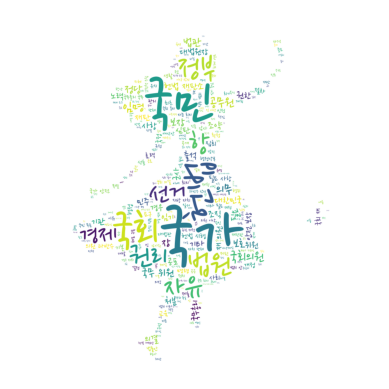

In [94]:
mask4 = cv2.imread('data/test3.png')

from wordcloud import STOPWORDS
불용어 = STOPWORDS | {'대통령', '법률'} # | : 집합 합연산자
불용어 = {'대통령', '법률'}
불용어 = set(['대통령', '법률', '조', '때'])

wordCl = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                width=1200, # 생성될 이미지 가로길이
                height=1200,
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최개갯수
                relative_scaling=0.2,  # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis',
#                 max_font_size=80, # 최대 폰트 사이즈
#                 min_font_size=10, # 최소 폰트 사이즈
                stopwords=불용어,
                mask=mask4
)
wordCl.generate(consti_noun)
plt.imshow(wordCl)
plt.axis('off')
plt.show

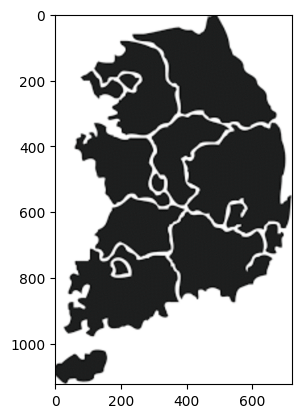

In [100]:
# mask5 = cv2.imread('data/south_korea.png') or
# convert('RGB') : 1채널이미지 -> 3채널
# convert('RGBA') : 1채널이미지 -> 4채널
img = Image.open('data/south_korea.png').convert('RGB')
mask5 = np.array(img)
mask5.shape
plt.imshow(mask5)

<function matplotlib.pyplot.show(close=None, block=None)>

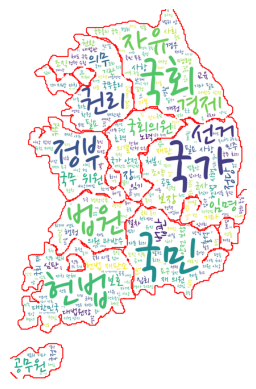

In [107]:
from wordcloud import STOPWORDS
불용어 = STOPWORDS | {'대통령', '법률'} # | : 집합 합연산자
불용어 = {'대통령', '법률'}
불용어 = set(['대통령', '법률', '조', '때', '항'])

wordCl = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white', # 배경색
                max_words=300, # 표시될 단어의 최개갯수
                relative_scaling=0.2,  # 단어 빈도에 따른 크기 차이 조정
                colormap='viridis',
                stopwords=불용어,
                mask=mask5,
                contour_color='red',
                contour_width=3
)
wordCl.generate(consti_noun)
plt.imshow(wordCl)
plt.axis('off')
plt.show

In [108]:
# 생성된 wordcloud 저장
wordCl.to_file('data/korea.jpg') # jpg나 png

# 단어의 빈도수 시각화(nltk.Text)


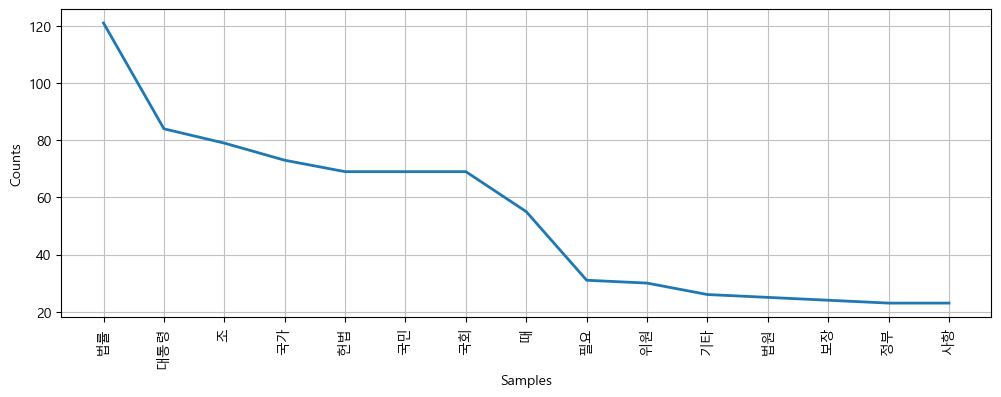

In [114]:
import nltk
data_text = nltk.Text(noun_consti2)
plt.figure(figsize=(12, 4))
plt.rc('font', family='Malgun Gothic')
data_text.plot(15)
plt.show()

In [118]:
data_text.vocab().most_common(20)

[('법률', 121),
 ('대통령', 84),
 ('조', 79),
 ('국가', 73),
 ('헌법', 69),
 ('국민', 69),
 ('국회', 69),
 ('때', 55),
 ('필요', 31),
 ('위원', 30),
 ('기타', 26),
 ('법원', 25),
 ('보장', 24),
 ('정부', 23),
 ('사항', 23),
 ('국무', 23),
 ('항', 22),
 ('자유', 21),
 ('권리', 21),
 ('선거', 21)]

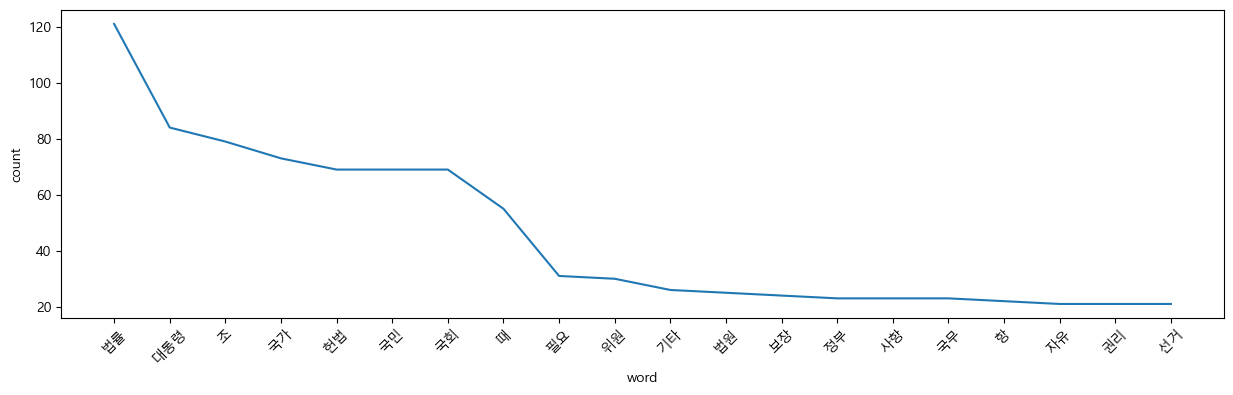

In [123]:
word, counts = zip(*data_text.vocab().most_common(20))
# print(word, counts)
plt.figure(figsize=(15,4))
plt.plot(word, counts)
plt.xticks(rotation=45)
plt.xlabel('word')
plt.ylabel('count')
plt.show()

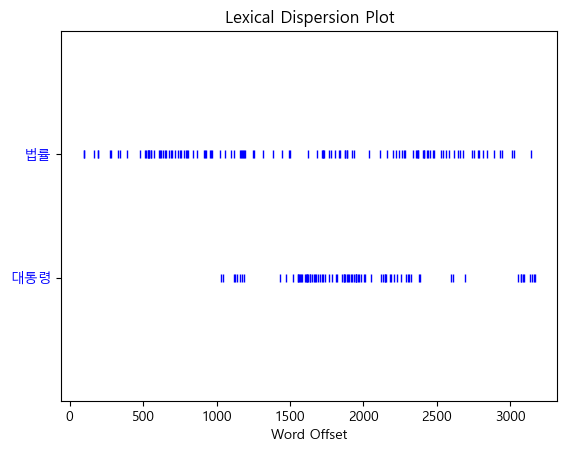

In [124]:
data_text.dispersion_plot(['법률', '대통령'])

# 6. 워드 임베딩
- 단어간 벡터 계산 -> 단어간 유사성 도출

In [8]:
import requests
from bs4 import BeautifulSoup
rss_url = 'https://fs.jtbc.co.kr/RSS/economy.xml'
jtbc_response = requests.get(rss_url)
soup = BeautifulSoup(jtbc_response.content, 'xml')
soup
link_el = soup.select('item link')
link_list = [el.text for el in link_el]
print(link_list, len(link_list))

['https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220943', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220949', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220832', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220765', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220766', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220665', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220651', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220627', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220516', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220366', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220365', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220169', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12220180', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12219888', 'https://news.jtbc.co.kr/article/article.aspx?news_id=NB12219

In [9]:
'''각 link들의 뉴스 기사 (x) -> 명사만 : 
    [['등촌', '재건축', '명사1', ...], 
     ['캠핑장', '재건축', '명사2', ...], ...]

''' 
from konlpy.tag import Kkma
kkma = Kkma()
news = []
for link in link_list:
    response = requests.get(link)
#     print(response.status_code)
    news_soup = BeautifulSoup(response.content, 'html.parser')
    title = news_soup.select_one('title').text
    description = str(news_soup.select_one('meta[name="description"]'))
    noun_list = kkma.nouns(title + ' ' + description)
    불용어 = {'뉴스', '앵커'}
    noun_list = [word for word in noun_list if word not in 불용어]
    print(noun_list)
    news.append(noun_list)

['촌', '촌주공', '주공', '전', '홍수', '예상', '눈치', '눈치게임', '게임', '시작', '단군', '이래', '최대', '규모', '건축', '불리', '아파트', '입주', '다음', '말', '대규모', '전세', '전세매물', '매물', '현장']
['실제', '완전', '사기', '캠핑', '캠핑장', '장', '관리', '소홀', '예약', '때', '플랫폼', '사진', '기대', '당황', '분']
['요즘', '끼', '편의점', '정도', '정도일', '일', '줄', '2', '2만', '만', '원', '육박', '점심', '점심값', '값', '도시락', '때', '7000', '7000원', '식비', '부담']
['오늘', '겠다', '말', '이유', '편의점', '도시락', '7', '7천원', '천', '원', '시대', '주머니', '직장인', '자취생', '눈앞', '아람', '기자']
['경영권', '분쟁', '주', '표', '표대결', '대결', '로', '롤러', '롤러코스터', '코스터', '고려', '고려아연', '아연', '주가', '오늘', '28', '28일', '일', '장', '장중', '중', '15', '포인트', '말', '달', '이어진', '공개', '공개매수', '매수', '절차', '마무리', '뚜껑', '어보']
['결혼', '돈', '걱정', '예비', '예비부부', '부부', '저출산', '문제지', '현실', '결혼식', '비용', '문제', '소식', '정', '정아람', '아람', '기자', '전', '전해드', '해드']
['예비', '예비부부', '부부', '웨딩', '물가', '올해', '예식장', '비용', '21', '한편', '결혼식', '비싸져', '식', '소식', '정', '정아람', '아람', '기자', '내년', '5', '5월', '월', '결혼']
['20', '20대', '대', '정규직', '비중', '역대', '최고', '10', '

In [10]:
# rss의 title과 description => 명사 추출 => 워드임베딩(단어간 거리 계산)
import requests
from bs4 import BeautifulSoup
rss_url = 'https://fs.jtbc.co.kr/RSS/economy.xml'
jtbs_response = requests.get(rss_url)
soup = BeautifulSoup(jtbc_response.content, 'xml')
news = []
item_elems = soup.find_all('item')
for item_elem in item_elems:
    title = item_elem.find('title').text
    description = item_elem.find('description').text
#     print(title+' '+description)
    article = title + ' '+description.replace('[앵커]', ' ')
    noun_list1 = kkma.nouns(article)
    # 보통명사(NNG), 고유명사(NNP)
    noun_list = [word for word, tag in kkma.pos(article) if tag in ('NNG', 'NNP')]
    news.append(noun_list)
print(news[:3])

[['촌', '주공', '전', '홍수', '예상', '눈치', '게임', '시작', '단군', '이래', '최대', '규모', '건축', '불리', '촌', '주공', '아파트', '입주', '다음', '말', '시작', '대규모', '입주', '전세', '매물', '현장', '분위기', '이'], ['실제', '완전', '사기', '캠핑', '장', '관리', '소홀', '캠핑', '장', '예약', '때', '예약', '플랫폼', '사진', '실제', '불만', '경우', '앞', '예약', '플랫폼', '책임', '강화', '아람', '기자', '기자', '인터넷', '카페'], ['요즘', '끼', '편의점', '정도', '일', '줄', '육박', '점심', '값', '편의점', '도시락', '끼', '때', '편의점', '도시락', '식비', '부담', '아람', '기자', '기자', '서울', '한']]


In [11]:
# 워드 임베딩 (단어간 거리 계산)
# pip install gensim
from gensim.models import Word2Vec

In [25]:
model = Word2Vec(news, # 학습데이터 2차원
                window=10, # 각 단어의 좌우10개 단어를 학습 컨텐츠로 사용
                min_count=2, # 학습데이터에서 2회 이상 등장한 단어만 학습.
                workers=-1 # 병렬처리 core수. -1: 모든 가용 코어 사용
                )
model

In [18]:
model.wv.most_similar('기자')

[('가격', 0.18890605866909027),
 ('전', 0.18855659663677216),
 ('코스터', 0.18359005451202393),
 ('예산', 0.18345923721790314),
 ('김', 0.17804878950119019),
 ('내년', 0.16072483360767365),
 ('직전', 0.15974178910255432),
 ('아파트', 0.15923379361629486),
 ('실제', 0.15861040353775024),
 ('어제', 0.15196380019187927)]

In [15]:
model.wv.most_similar('아파트', topn=3)

[('아연', 0.2122785449028015),
 ('불리', 0.19188855588436127),
 ('매출', 0.16693152487277985)]